# Exploring Rhea

## Loading the node and edge info 

In [ ]:
from lipinet.parse_rhea import parse_rhea_data

rhea_results = parse_rhea_data(verbose=False)
df_rhea_nodes = rhea_results['df_nodes']
df_rhea_edges = rhea_results['df_edges']

In [2]:
df_rhea_nodes

,node_id,Equation,ChEBI identifier,chebi_name,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome),layer,ec_level
0,RHEA:22864,L-lysine = D-lysine,CHEBI:32551;CHEBI:32557,L-lysine;D-lysine,EC:5.1.1.5,654.0,GO:0018113 lysine racemase activity,NaN,rhea_reactionid,NaN
1,RHEA:22868,thioglycolate + 3-chloro-L-alanine = S-carboxy...,CHEBI:30066;CHEBI:58132;CHEBI:57662;CHEBI:1799...,thioglycolate;3-chloro-L-alanine;S-carboxymeth...,EC:4.5.1.5,1.0,GO:0050272 S-carboxymethylcysteine synthase ac...,NaN,rhea_reactionid,NaN
2,RHEA:22872,L-prolyl-[collagen] + 2-oxoglutarate + O2 = tr...,CHEBI:50342;CHEBI:16810;CHEBI:15379;CHEBI:8542...,L-proline residue;2-oxoglutarate;O2;trans-3-hy...,EC:1.14.11.7,687.0,GO:0019797 procollagen-proline 3-dioxygenase a...,NaN,rhea_reactionid,NaN
3,RHEA:22876,(R)-mandelamide + H2O = (R)-mandelate + NH4(+),CHEBI:17352;CHEBI:15377;CHEBI:32382;CHEBI:28938,(R)-mandelamide;H2O;(R)-mandelate;NH4(+),EC:3.5.1.86,1.0,GO:0050537 mandelamide amidase activity,NaN,rhea_reactionid,NaN
4,RHEA:22880,L-arogenate + 2-oxoglutarate = prephenate + L-...,CHEBI:58180;CHEBI:16810;CHEBI:29934;CHEBI:29985,L-arogenate;2-oxoglutarate;prephenate;L-glutamate,EC:2.6.1.79,238.0,GO:0033854 glutamate-prephenate aminotransfera...,NaN,rhea_reactionid,NaN
...,...,...,...,...,...,...,...,...,...,...
37667,EC:2.3.1.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37668,EC:3.5.1.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37669,EC:2.6.1.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37670,EC:2.3.1.150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec


In [3]:
df_rhea_edges

,source_id,target_id,ec_level,source_layer,target_layer,interlayer,edge_type
0,EC:5,EC:5.1,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
1,EC:4,EC:4.5,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
2,EC:1,EC:1.14,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
3,EC:3,EC:3.5,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
4,EC:2,EC:2.6,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
...,...,...,...,...,...,...,...
107429,RHEA:22844,EC:1.14.14.135,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
107430,RHEA:22848,NaN,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
107431,RHEA:22852,EC:2.6.1.51,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
107432,RHEA:22856,EC:2.3.1.150,NaN,rhea_reactionid,rhea_ec,False,reaction_ec


In [4]:
from graph_tool.all import Graph, GraphView, graph_draw
import graph_tool as gt

from onionnet import OnionNet
import onionnet.visualisation

import pandas as pd

import onionnet.exporter 

## Building the network with OnionNet

In [5]:
onion = OnionNet()

onion.grow_onion(df_nodes=df_rhea_nodes,
           df_edges=df_rhea_edges,
           node_prop_cols=df_rhea_nodes.columns.to_list(),
           edge_prop_cols=df_rhea_edges.columns.to_list(),
           drop_na=True,
           drop_duplicates=True)

In [6]:
onion.core.graph

<Graph object, directed, with 37672 vertices and 97383 edges, 12 internal vertex properties, 7 internal edge properties, at 0x30c3bc9e0>

In [7]:
list(onion.core.graph.vp)

['layer_hash',
 'node_id_hash',
 'node_id',
 'Equation',
 'ChEBI identifier',
 'chebi_name',
 'EC number',
 'Enzymes',
 'Gene Ontology',
 'Cross-reference (Reactome)',
 'layer',
 'ec_level']

In [8]:
df_rhea_nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37672 entries, 0 to 37671
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   node_id                     37672 non-null  object 
 1   Equation                    17614 non-null  object 
 2   ChEBI identifier            17614 non-null  object 
 3   chebi_name                  31186 non-null  object 
 4   EC number                   7563 non-null   object 
 5   Enzymes                     17614 non-null  float64
 6   Gene Ontology               4364 non-null   object 
 7   Cross-reference (Reactome)  912 non-null    object 
 8   layer                       37672 non-null  object 
 9   ec_level                    6486 non-null   object 
dtypes: float64(1), object(9)
memory usage: 2.9+ MB


Decode property labels that were encoded 

In [10]:
onion.decode_property_labels_bulk(df=df_rhea_nodes, encoded_prop_type='v')

V property 'node_id_decoded' created successfully.
V property 'equation_decoded' created successfully.
V property 'chebi_identifier_decoded' created successfully.
V property 'chebi_name_decoded' created successfully.
V property 'ec_number_decoded' created successfully.
Enzymes prop left as is, no decoding needed (not an object type)
V property 'gene_ontology_decoded' created successfully.
V property 'cross_reference_reactome_decoded' created successfully.
V property 'layer_decoded' created successfully.
V property 'ec_level_decoded' created successfully.


In [11]:
onion.decode_property_labels_bulk(df=df_rhea_edges, encoded_prop_type='e')

E property 'source_id_decoded' created successfully.
E property 'target_id_decoded' created successfully.
E property 'ec_level_decoded' created successfully.
E property 'source_layer_decoded' created successfully.
E property 'target_layer_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)
E property 'edge_type_decoded' created successfully.


In [12]:
df_rhea_edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107434 entries, 0 to 107433
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   source_id     107434 non-null  object
 1   target_id     97383 non-null   object
 2   ec_level      6479 non-null    object
 3   source_layer  107434 non-null  object
 4   target_layer  107434 non-null  object
 5   interlayer    107434 non-null  bool  
 6   edge_type     107434 non-null  object
dtypes: bool(1), object(6)
memory usage: 5.0+ MB


In [25]:
onion.core.layer_code_to_name

{0: 'rhea_reactionid', 1: 'rhea_chebiid', 2: 'rhea_ec'}

## Filtering the network

### Getting all the EC nodes and visualising

In [16]:
filter1 = lambda v: onion.core.graph.vp['layer_decoded'][v] == 'rhea_ec'
filtered_view = onion.searcher.compose_filters(filter_funcs=[filter1], mode="or")
filtered_view

<GraphView object, directed, with 6486 vertices and 6479 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x30ef84c50, at 0x30ef847d0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x30ef84c50, at 0x30ef863c0>, False), at 0x30ef84c50>

In [17]:
onionnet.exporter.export_info(filtered_view, mode='v')

,v_int,layer_hash,node_id_hash,node_id,Equation,ChEBI identifier,chebi_name,EC number,Enzymes,Gene Ontology,...,ec_level,node_id_decoded,equation_decoded,chebi_identifier_decoded,chebi_name_decoded,ec_number_decoded,gene_ontology_decoded,cross_reference_reactome_decoded,layer_decoded,ec_level_decoded
0,31186,2,31186,31186,17614,17093,30331,8,NaN,10,...,1,EC:5,nan,nan,nan,nan,nan,nan,rhea_ec,main_class
1,31187,2,31187,31187,17614,17093,30331,8,NaN,10,...,1,EC:4,nan,nan,nan,nan,nan,nan,rhea_ec,main_class
2,31188,2,31188,31188,17614,17093,30331,8,NaN,10,...,1,EC:1,nan,nan,nan,nan,nan,nan,rhea_ec,main_class
3,31189,2,31189,31189,17614,17093,30331,8,NaN,10,...,1,EC:3,nan,nan,nan,nan,nan,nan,rhea_ec,main_class
4,31190,2,31190,31190,17614,17093,30331,8,NaN,10,...,1,EC:2,nan,nan,nan,nan,nan,nan,rhea_ec,main_class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6481,37667,2,37667,37667,17614,17093,30331,8,NaN,10,...,4,EC:2.3.1.41,nan,nan,nan,nan,nan,nan,rhea_ec,full_ec
6482,37668,2,37668,37668,17614,17093,30331,8,NaN,10,...,4,EC:3.5.1.35,nan,nan,nan,nan,nan,nan,rhea_ec,full_ec
6483,37669,2,37669,37669,17614,17093,30331,8,NaN,10,...,4,EC:2.6.1.51,nan,nan,nan,nan,nan,nan,rhea_ec,full_ec
6484,37670,2,37670,37670,17614,17093,30331,8,NaN,10,...,4,EC:2.3.1.150,nan,nan,nan,nan,nan,nan,rhea_ec,full_ec


<div style="border:1px solid #e34a4a; padding:10px; background-color:#fee;">
⚠️ Warning: <br>

At first it might look like we have an error here with the `Equation`, `ChEBI identifier`, `chebi_name` and `EC number` values, afterall why would the ChEBI Identifier values for all EC cells be `17093`? 

But remember that these are the column values as encoded values; we are more interested instead in their values _after_ decoding (e.g. `chebi_identifier_decoded`). In which case they are all `nan`, as we would expect since these EC numbers don't have ChEBI values etc.
</div>

In [37]:
onionnet.exporter.export_info(filtered_view, mode='v')[['layer_decoded','ec_level_decoded']].value_counts()

layer_decoded  ec_level_decoded
rhea_ec        full_ec             6150
               subsubclass          253
               subclass              76
               main_class             7
Name: count, dtype: int64

Now we can view the 7 'families' of Enzyme Classifications

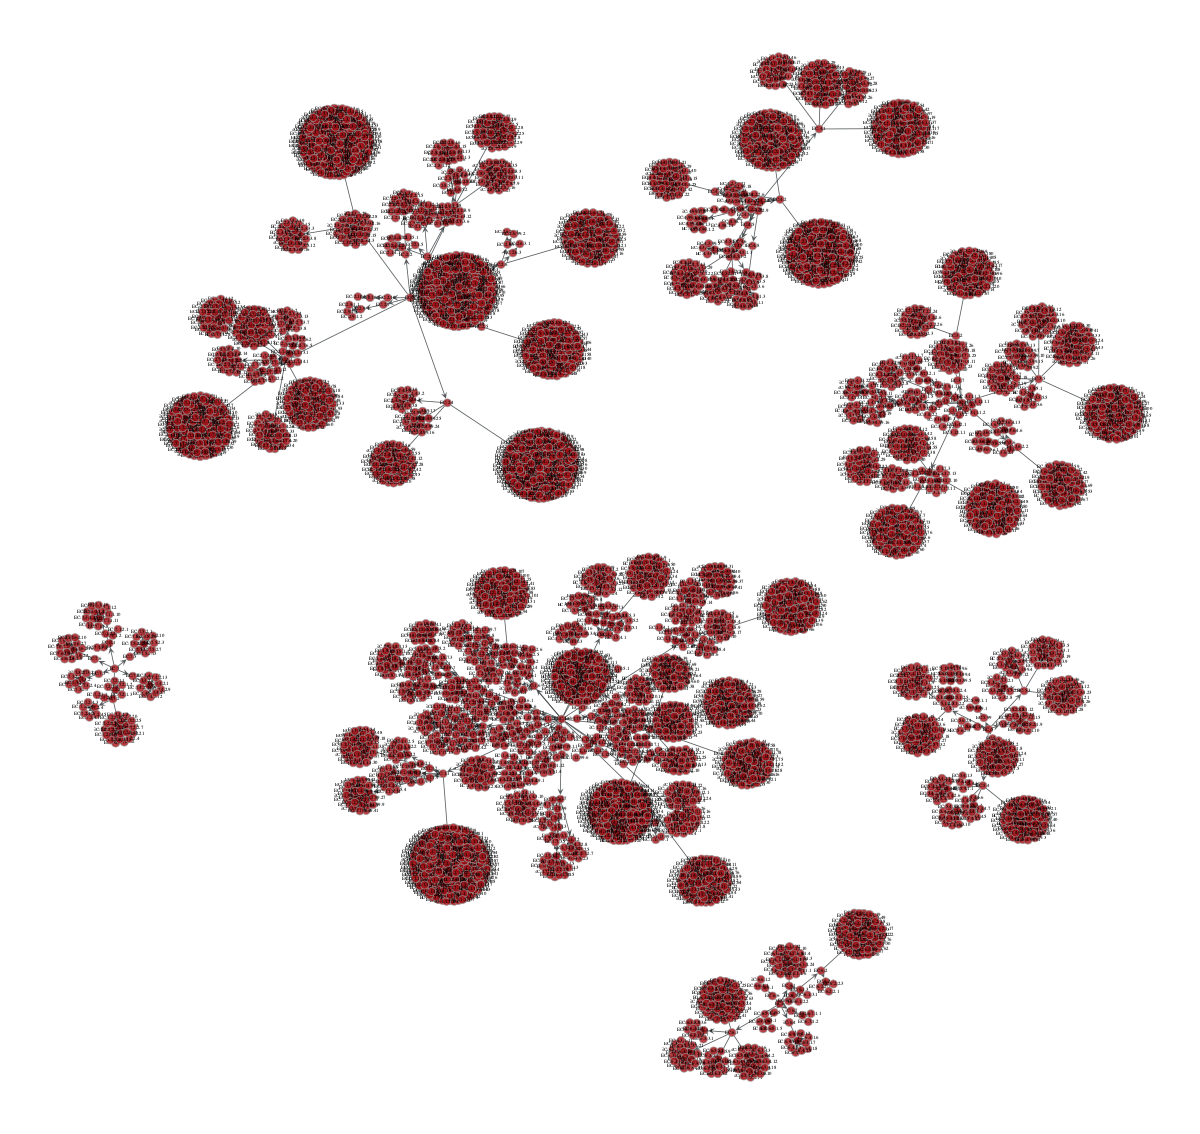

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x30ef84c50, at 0x1691eec00>

In [18]:
graph_draw(
    filtered_view,
    vertex_text=filtered_view.vp['node_id_decoded'], 
    vertex_text_position=-2,
    vertex_size=4,
    vertex_text_color='black'
    )

### Getting specific nodes based on the `reaction IDs` (e.g. `RHEA:23128`)

Filtered graph contains 8 vertices and 7 edges.


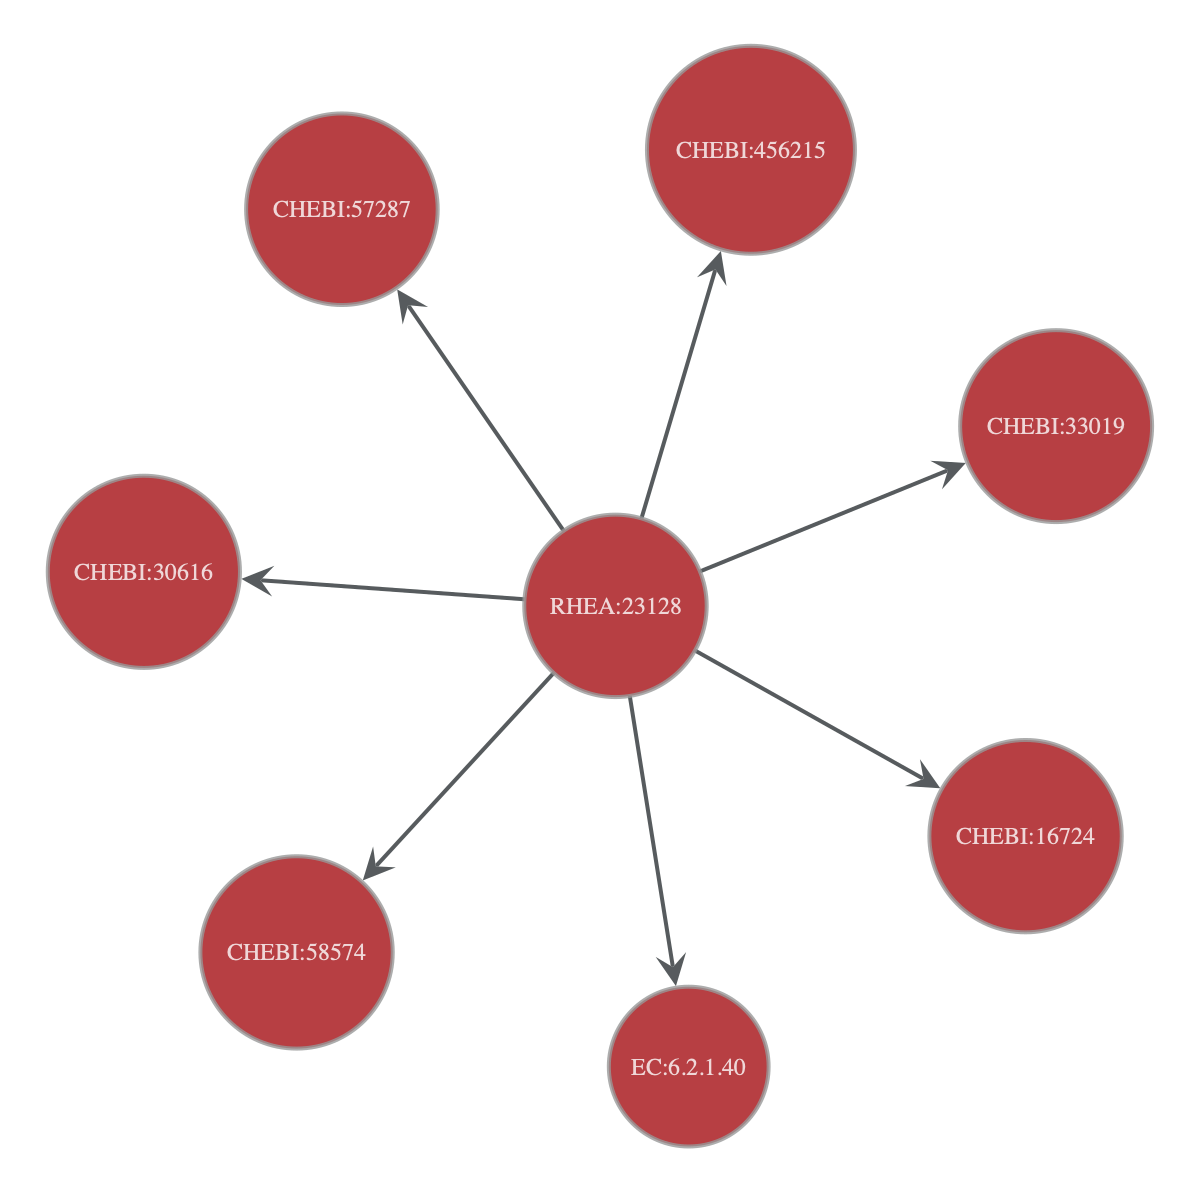

<GraphView object, directed, with 8 vertices and 7 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x16b481fa0, at 0x30f1df800>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x16b481fa0, at 0x30f1df6e0>, False), at 0x16b481fa0>

In [19]:
# search for a specific node (noi = node of interest)
noi = onion.get_vertex_by_name_tuple(layer_name='rhea_reactionid', node_id_str='RHEA:23128')

onion.searcher.search(start_node_idx=noi, 
                      max_dist=2, 
                      node_text_prop='node_id_decoded',
                      vertex_text_position=-1,
                      vertex_size=20)

In [20]:
df_rhea_edges[df_rhea_edges['target_layer']=='rhea_chebiid']['target_id'].value_counts()[:30]

target_id
CHEBI:15378     9836
CHEBI:15377     6418
CHEBI:15379     2830
CHEBI:57287     1565
CHEBI:58349     1326
CHEBI:57783     1320
CHEBI:30616     1308
CHEBI:57540     1207
CHEBI:33019     1158
CHEBI:57945     1136
CHEBI:16526     1042
CHEBI:43474     1024
CHEBI:59789      928
CHEBI:58210      855
CHEBI:456216     855
CHEBI:57856      847
CHEBI:57618      846
CHEBI:58223      629
CHEBI:28938      532
CHEBI:456215     523
CHEBI:17499      453
CHEBI:13193      453
CHEBI:16240      452
CHEBI:16810      448
CHEBI:57288      382
CHEBI:30031      348
CHEBI:29033      266
CHEBI:33737      261
CHEBI:33738      261
CHEBI:29101      259
Name: count, dtype: int64

### Getting specific nodes based on the `chebi IDs` (e.g. `CHEBI:29101`)

Filtered graph contains 260 vertices and 259 edges.


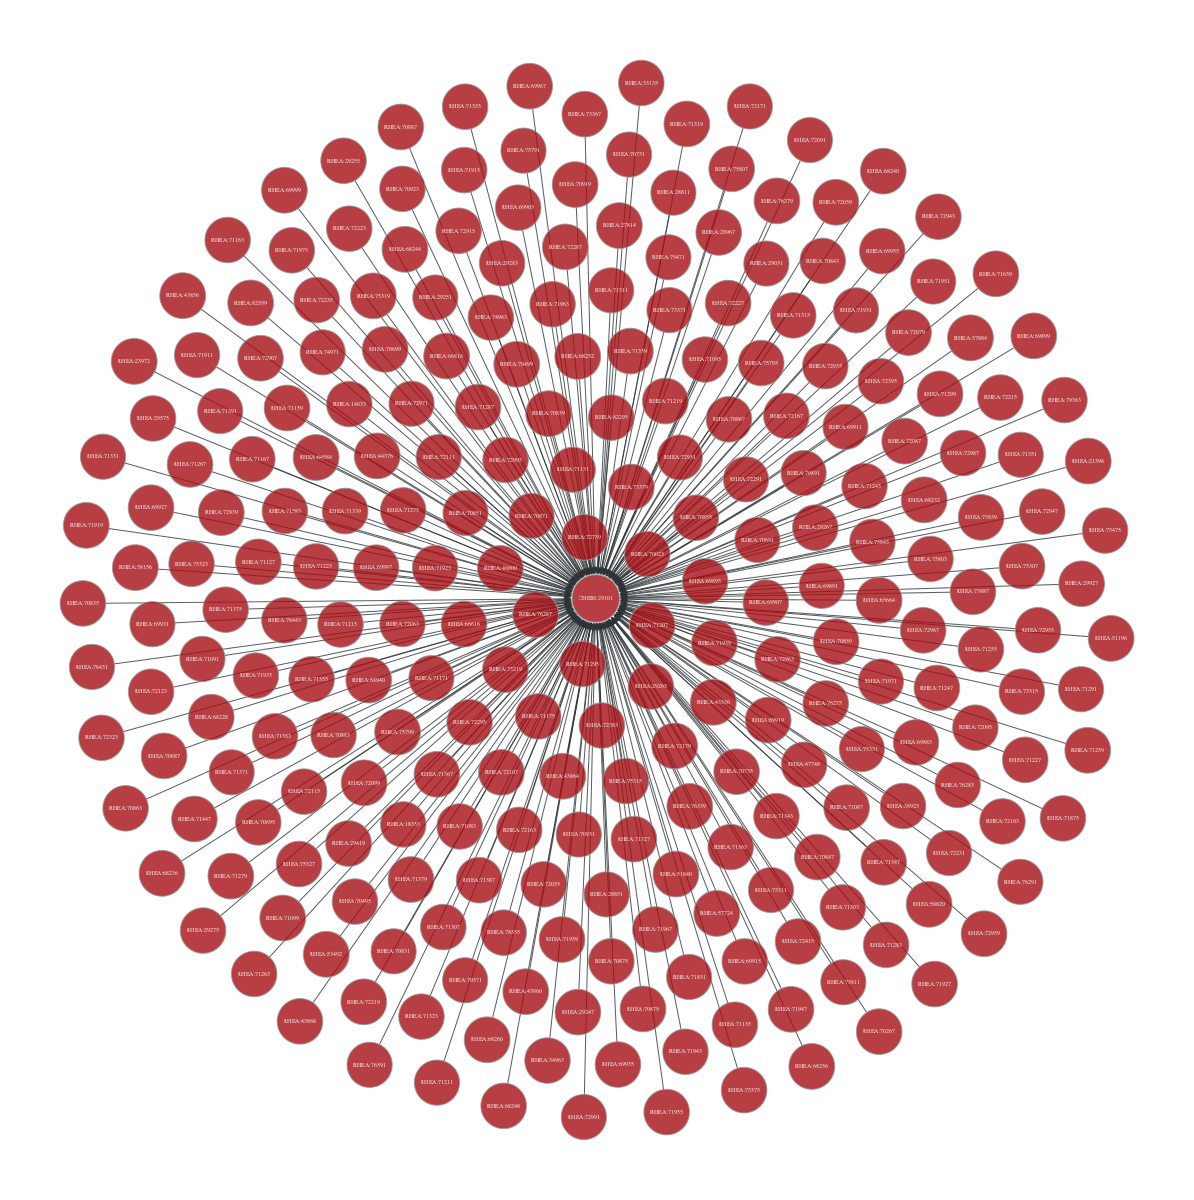

<GraphView object, directed, with 260 vertices and 259 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x30e1d4ad0, at 0x30e226120>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x30e1d4ad0, at 0x30e227fe0>, False), at 0x30e1d4ad0>

In [23]:
# search for a specific node (noi = node of interest)
noi = onion.get_vertex_by_name_tuple(layer_name='rhea_chebiid', node_id_str='CHEBI:29101')

onion.searcher.search(start_node_idx=noi, 
                      max_dist=4, 
                      node_text_prop='node_id_decoded',
                      vertex_text_position=-1,
                      vertex_size=5, 
                      direction='bi')

### Getting all nodes up and/or downstream of a particular `EC number` (e.g. `EC:6.2.1.40`)

We can begin with a bidirectional search of a certain EC number (note this was in the visualisation filter we did earlier)

Filtered graph contains 5 vertices and 4 edges.


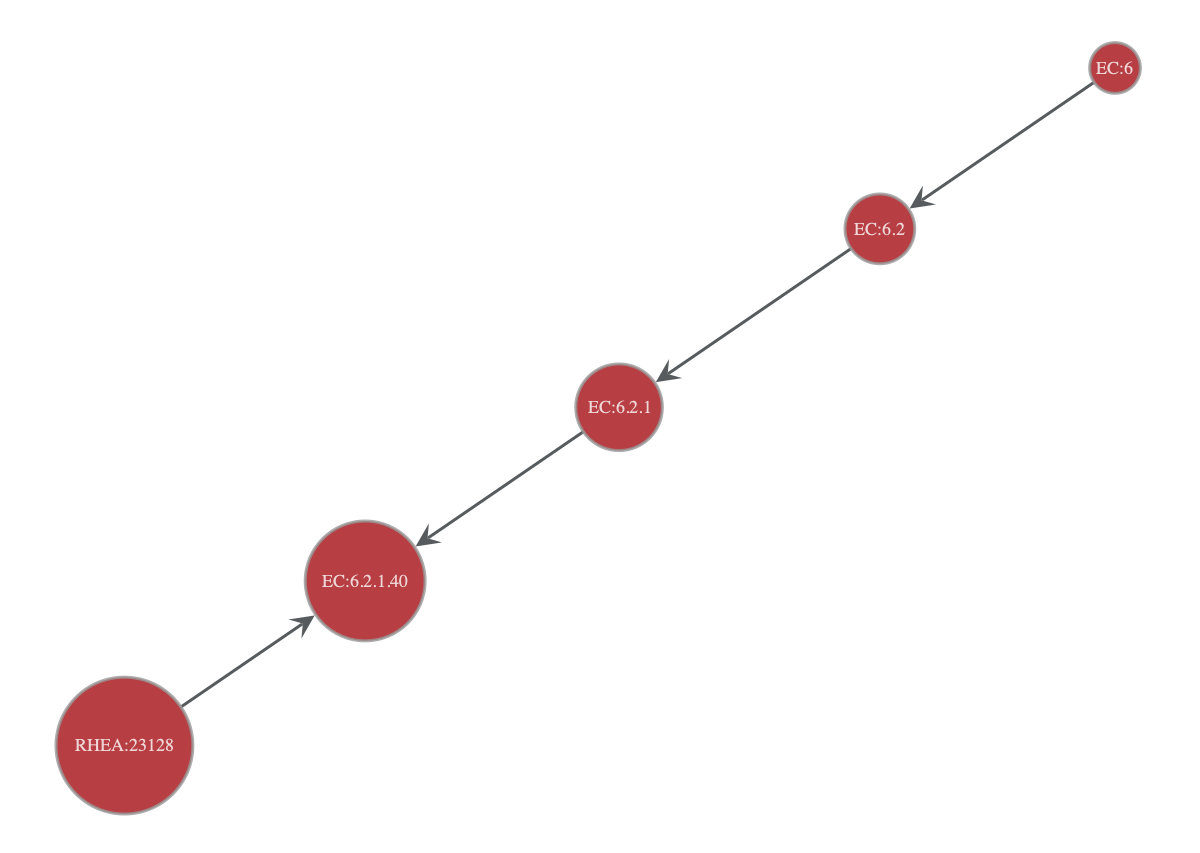

<GraphView object, directed, with 5 vertices and 4 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x15e5ab770, at 0x148890440>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x15e5ab770, at 0x30f1df920>, False), at 0x15e5ab770>

In [38]:
# search for a specific node (noi = node of interest)
noi = onion.get_vertex_by_name_tuple(layer_name='rhea_ec', node_id_str='EC:6.2.1.40')

onion.searcher.search(start_node_idx=noi, 
                      max_dist=4, 
                      node_text_prop='node_id_decoded',
                      vertex_text_position=-1,
                      vertex_size=15, 
                      direction='bi')

Or we could also pick a higher level of EC and then get all the children of that node

Filtered graph contains 75 vertices and 74 edges.


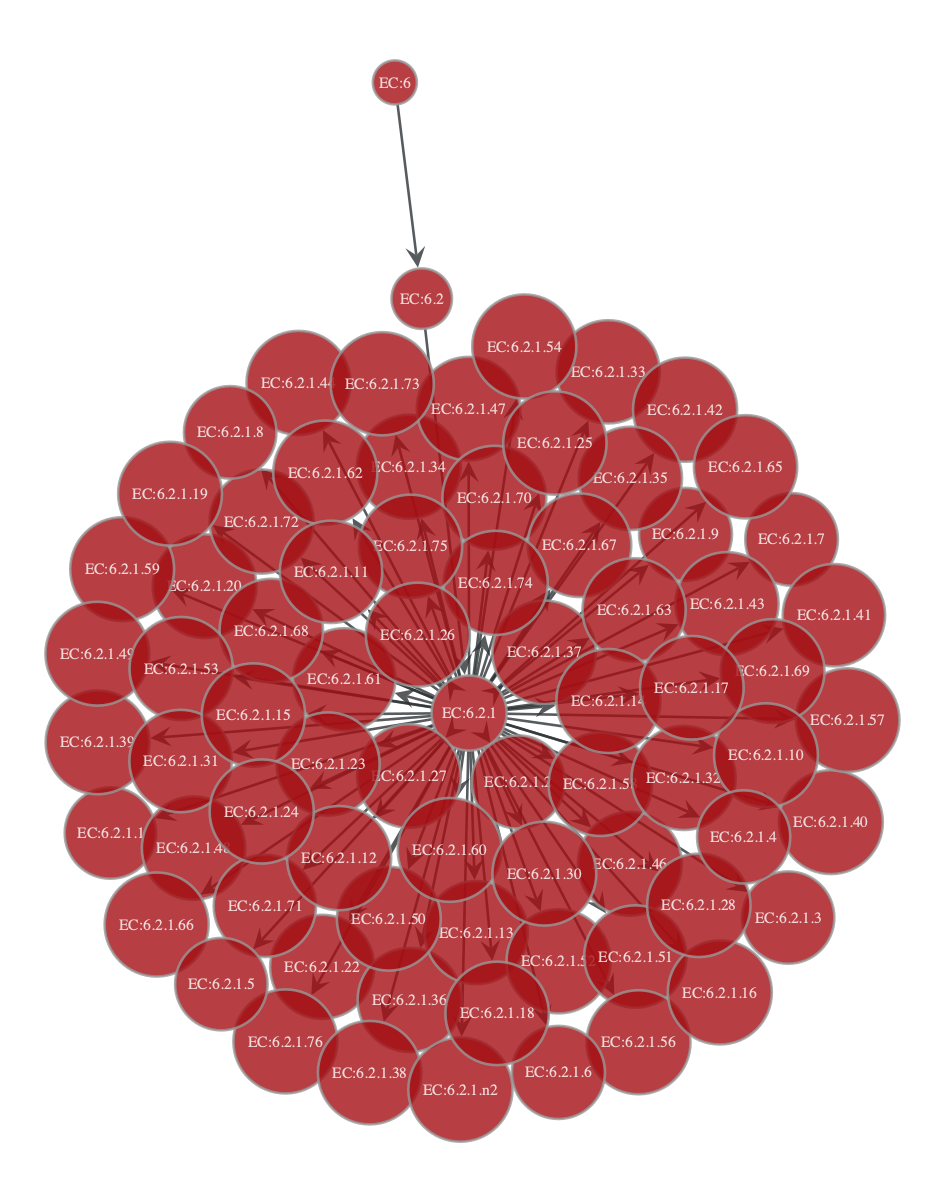

<GraphView object, directed, with 75 vertices and 74 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x30f1ddbb0, at 0x148896fc0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x30f1ddbb0, at 0x1488954f0>, False), at 0x30f1ddbb0>

In [41]:
# search for a specific node (noi = node of interest)
noi = onion.get_vertex_by_name_tuple(layer_name='rhea_ec', node_id_str='EC:6.2.1')

onion.searcher.search(start_node_idx=noi, 
                      max_dist=4, 
                      node_text_prop='node_id_decoded',
                      vertex_text_position=-1,
                      vertex_size=13, 
                      direction='bi')

### Combining multiple conditional filters using `lambda` and `onion.compose_filters()`

We can combine filters using `lambda` and `onion.compose_filters()`. We can use either `and` or `or` modes.

For example we might want to filter those nodes where the ec_level_decoded is either main class or subclass.

In [62]:
filter1 = lambda v: onion.core.graph.vp['ec_level_decoded'][v] == 'main_class'
filter2 = lambda v: onion.core.graph.vp['ec_level_decoded'][v] == 'subclass'
filtered_view = onion.compose_filters([filter1, filter2], mode="or")
filtered_view

<GraphView object, directed, with 83 vertices and 76 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x30f109a90, at 0x30f2c8e00>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x30f109a90, at 0x30ef867b0>, False), at 0x30f109a90>

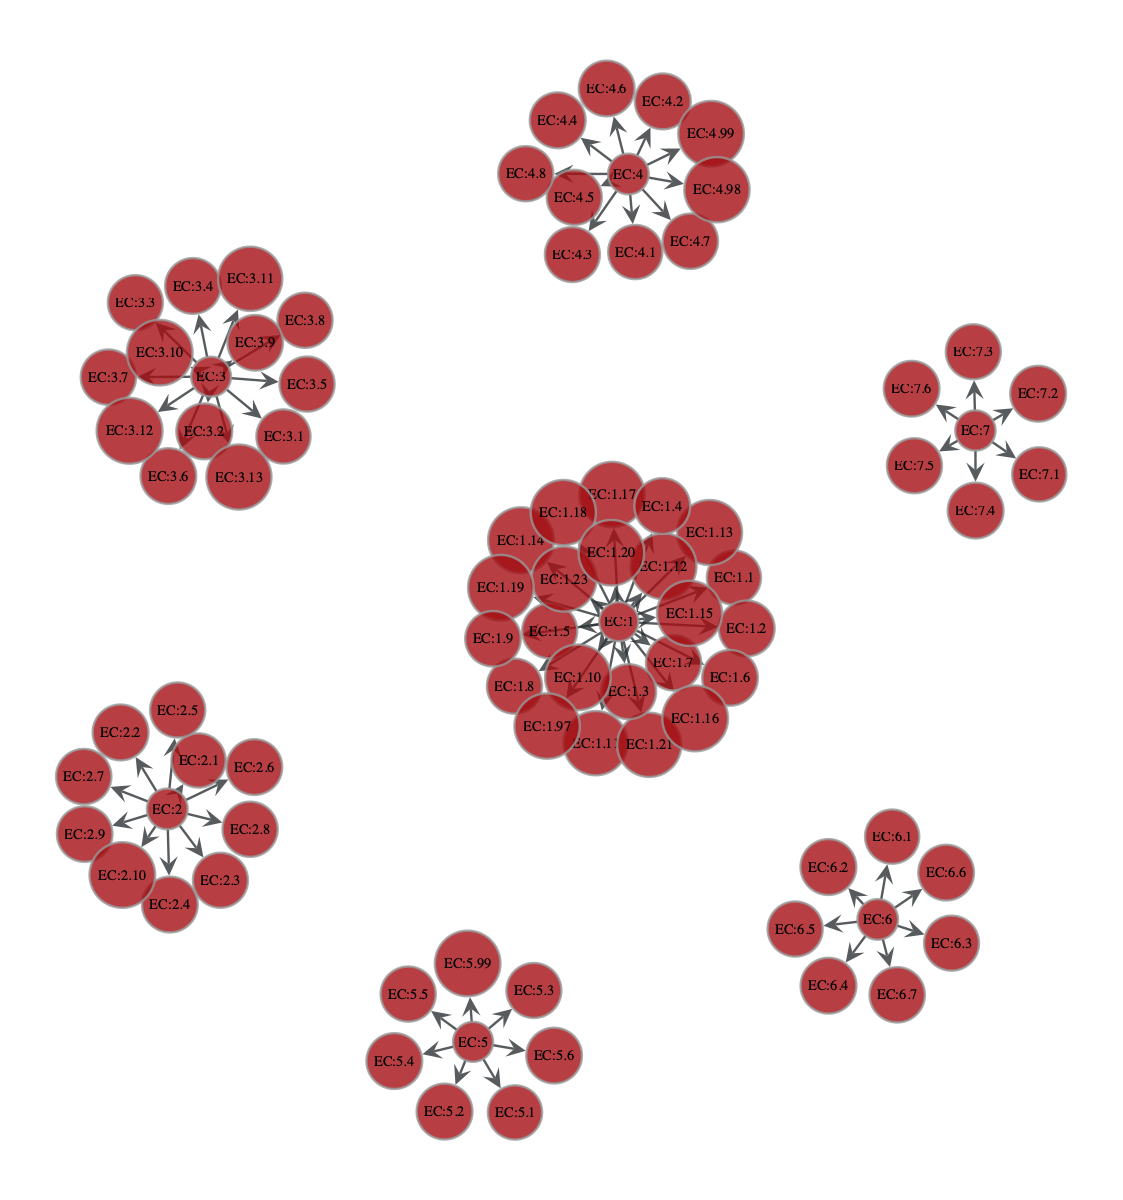

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x30f109a90, at 0x30f2d1dc0>

In [67]:
graph_draw(
    filtered_view,
    vertex_size=12,
    vertex_text_color='black',
    vertex_text=filtered_view.vp['node_id_decoded'],
    )

## Analyse the Rhea network

Now that we've shown how to build and filter the Rhea network, what can we actually do with it to start generating interesting insights?

We could start by answering the following basic questions:
1. Which ChEBI compounds are mostly commonly involved in Rhea reactions?
2. Which reactions have the largest number of compounds involved?
3. What are the 'bottleneck' reactions? (i.e. betweenness on reactions that share a compound)

### Identify the top metabolic 'hub' compounds

In [71]:
filter1 = lambda v: onion.core.graph.vp['layer_decoded'][v] != 'rhea_ec'
filtered_view = onion.searcher.compose_filters(filter_funcs=[filter1], mode="or")
filtered_view

<GraphView object, directed, with 31186 vertices and 83052 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x30e232f30, at 0x30f2cad80>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x30e232f30, at 0x30e225730>, False), at 0x30e232f30>

In [72]:
onionnet.exporter.export_info(filtered_view, mode='v')

,v_int,layer_hash,node_id_hash,node_id,Equation,ChEBI identifier,chebi_name,EC number,Enzymes,Gene Ontology,...,ec_level,node_id_decoded,equation_decoded,chebi_identifier_decoded,chebi_name_decoded,ec_number_decoded,gene_ontology_decoded,cross_reference_reactome_decoded,layer_decoded,ec_level_decoded
0,0,0,0,0,0,0,0,0,654.0,0,...,0,RHEA:22864,L-lysine = D-lysine,CHEBI:32551;CHEBI:32557,L-lysine;D-lysine,EC:5.1.1.5,GO:0018113 lysine racemase activity,nan,rhea_reactionid,nan
1,1,0,1,1,1,1,1,1,1.0,1,...,0,RHEA:22868,thioglycolate + 3-chloro-L-alanine = S-carboxy...,CHEBI:30066;CHEBI:58132;CHEBI:57662;CHEBI:1799...,thioglycolate;3-chloro-L-alanine;S-carboxymeth...,EC:4.5.1.5,GO:0050272 S-carboxymethylcysteine synthase ac...,nan,rhea_reactionid,nan
2,2,0,2,2,2,2,2,2,687.0,2,...,0,RHEA:22872,L-prolyl-[collagen] + 2-oxoglutarate + O2 = tr...,CHEBI:50342;CHEBI:16810;CHEBI:15379;CHEBI:8542...,L-proline residue;2-oxoglutarate;O2;trans-3-hy...,EC:1.14.11.7,GO:0019797 procollagen-proline 3-dioxygenase a...,nan,rhea_reactionid,nan
3,3,0,3,3,3,3,3,3,1.0,3,...,0,RHEA:22876,(R)-mandelamide + H2O = (R)-mandelate + NH4(+),CHEBI:17352;CHEBI:15377;CHEBI:32382;CHEBI:28938,(R)-mandelamide;H2O;(R)-mandelate;NH4(+),EC:3.5.1.86,GO:0050537 mandelamide amidase activity,nan,rhea_reactionid,nan
4,4,0,4,4,4,4,4,4,238.0,4,...,0,RHEA:22880,L-arogenate + 2-oxoglutarate = prephenate + L-...,CHEBI:58180;CHEBI:16810;CHEBI:29934;CHEBI:29985,L-arogenate;2-oxoglutarate;prephenate;L-glutamate,EC:2.6.1.79,GO:0033854 glutamate-prephenate aminotransfera...,nan,rhea_reactionid,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31181,31181,1,31181,31181,17614,17093,30326,8,NaN,10,...,0,CHEBI:4372,nan,nan,(6S)-6-hydroxy-3-oxo-alpha-ionone,nan,nan,nan,rhea_chebiid,nan
31182,31182,1,31182,31182,17614,17093,30327,8,NaN,10,...,0,CHEBI:58780,nan,nan,"2,6-dihydroxynicotinate",nan,nan,nan,rhea_chebiid,nan
31183,31183,1,31183,31183,17614,17093,30328,8,NaN,10,...,0,CHEBI:188998,nan,nan,alpha-D-xylulofuranose,nan,nan,nan,rhea_chebiid,nan
31184,31184,1,31184,31184,17614,17093,30329,8,NaN,10,...,0,CHEBI:140599,nan,nan,3-O-[alpha-D-xylosyl-(1->3)-alpha-D-xylosyl-(1...,nan,nan,nan,rhea_chebiid,nan


In [76]:
onionnet.exporter.export_info(filtered_view, mode='v')['layer_decoded'].value_counts()

layer_decoded
rhea_reactionid    17614
rhea_chebiid       13572
Name: count, dtype: int64

In [75]:
filtered_view

<GraphView object, directed, with 31186 vertices and 83052 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x30e232f30, at 0x30f2cad80>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x30e232f30, at 0x30e225730>, False), at 0x30e232f30>

In [85]:
topx_num = 20
gview = filtered_view

# 1. compute degrees in the filtered view
deg_map = gview.degree_property_map("total")

# 2. collect only those vertices that are still in view AND are compounds
compound_vs = [v for v in gview.vertices() if gview.vp['layer_decoded'][v] == 'rhea_chebiid']

# 3. sort by degree, descending, take top x
topx = sorted(compound_vs, key=lambda v: deg_map[v], reverse=True)[:topx_num]

# 4. print or return
print(f"Top {topx_num} hub compounds in filtered Rhea graph:")
for v in topx:
    name = gview.vp['chebi_name_decoded'][v]   # or however you store the compound label
    print(f"  {name:12s} — {int(deg_map[v])} reactions")

Top 20 hub compounds in filtered Rhea graph:
  H(+)         — 9836 reactions
  H2O          — 6418 reactions
  O2           — 2830 reactions
  CoA          — 1565 reactions
  NADP(+)      — 1326 reactions
  NADPH        — 1320 reactions
  ATP          — 1308 reactions
  NAD(+)       — 1207 reactions
  diphosphate  — 1158 reactions
  NADH         — 1136 reactions
  CO2          — 1042 reactions
  phosphate    — 1024 reactions
  S-adenosyl-L-methionine — 928 reactions
  FMN          — 855 reactions
  ADP          — 855 reactions
  S-adenosyl-L-homocysteine — 847 reactions
  FMNH2        — 846 reactions
  UDP          — 629 reactions
  NH4(+)       — 532 reactions
  AMP          — 523 reactions


### Identify which reactions involve the largest number of compounds

In [97]:
# 1. compute degrees in the filtered view
deg_map = gview.degree_property_map("total")

# 2. collect only those vertices that are still in view AND are reactions
reaction_vs = [v for v in gview.vertices() if gview.vp['layer_decoded'][v] == 'rhea_reactionid']

# 3. sort by degree, descending, take top x
topx = sorted(reaction_vs, key=lambda v: deg_map[v], reverse=True)[:topx_num]

# 4. print or return
print(f"Top {topx_num} reactions in filtered Rhea graph by number of compounds involved:")
for v in topx:
    name = gview.vp['equation_decoded'][v]   # or however you store the compound label
    print(f"    {gview.vp['node_id_decoded'][v]}\t{int(deg_map[v])} compounds involved:\t{name:12s}")

Top 20 reactions in filtered Rhea graph by number of compounds involved:
    RHEA:64544	16 compounds involved:	L-tyrosine + holo-[ACP] + 7 malonyl-CoA + acetyl-CoA + 8 AH2 + 2 S-adenosyl-L-methionine + ATP + 4 H(+) = N-[(4E,6E,10S,12Z,14E)-6,10-dimethyl-3-oxohexadeca-4,6,12,14-tetraenoyl]-L-tyrosyl-[ACP] + 8 A + AMP + 2 S-adenosyl-L-homocysteine + 7 CO2 + diphosphate + 8 CoA + 6 H2O
    RHEA:69564	16 compounds involved:	L-asparagine + 3 L-isoleucine + L-histidine + L-leucine + L-ornithine + L-lysine + L-cysteine + L-aspartate + L-phenylalanine + L-glutamate + 12 ATP = bacitracin A + 12 AMP + 12 diphosphate + H2O + 12 H(+)
    RHEA:67324	15 compounds involved:	L-serine + 7 malonyl-CoA + acetyl-CoA + 2 S-adenosyl-L-methionine + ATP + 8 NADPH + 11 H(+) = (5S)-3-[(2E,6R,8E,10E,12E)-2,6-dimethyltetradeca-2,8,10,12-tetraenoyl]-5-(hydroxymethyl)pyrrolidine-2,4-dione + AMP + 2 S-adenosyl-L-homocysteine + 7 CO2 + diphosphate + 8 NADP(+) + 8 CoA + 6 H2O
    RHEA:67264	14 compounds involved:	(2S,

### Finding bottleneck reactions via betweenness centrality

In [ ]:
from graph_tool.topology import label_largest_component
from graph_tool.centrality import betweenness

# — assume you already have —
#   gview: GraphView of your full Rhea graph
#   vtype = gview.vp['type']     # “compound” or “reaction”
#   name  = gview.vp['name']     # human-readable label
#   (and you’ve built compound_vs similarly)

# 1. Extract reaction vertices from your view
reaction_vs = [v for v in gview.vertices() if gview.vp['layer_decoded'][v] == 'rhea_reactionid']

# 2. Build a new undirected graph h of only those reactions
h = Graph(directed=False)
h.vp['orig_id'] = h.new_vertex_property('int')  # to map back to gview

orig2new = {}
for orig in reaction_vs:
    nv = h.add_vertex()
    orig2new[orig] = nv
    h.vp['orig_id'][nv] = int(orig)

# 3. For each compound in the view, fully connect its incident reactions
compound_vs = [v for v in gview.vertices() if gview.vp['layer_decoded'][v] == 'rhea_chebiid']
for comp in compound_vs:
    # gather reactions incident to this compound (in the view)
    inc_reactions = []
    for e in comp.all_edges():
        # e.source() or e.target() may be the compound; pick the other end
        other = e.target() if e.source() == comp else e.source()
        if gview.vp['layer_decoded'][other] == 'reaction':
            inc_reactions.append(other)

    # fully connect each pair of those reactions in h
    for i in range(len(inc_reactions)):
        for j in range(i+1, len(inc_reactions)):
            h.add_edge(orig2new[inc_reactions[i]],
                       orig2new[inc_reactions[j]])

# 4. Compute betweenness centrality on the reaction–reaction graph
vertex_btw, _ = betweenness(h)

# 5. Report the top 5 bottleneck reactions
btw_list = sorted(h.vertices(),
                  key=lambda v: vertex_btw[v],
                  reverse=True)[:5]

print("Top 5 bottleneck reactions in your filtered graph:")
for v in btw_list:
    orig = h.vp['orig_id'][v]
    label = gview.vp['node_id_decoded'][gview.vertex(orig)]
    print(f"  {label:<20s} — betweenness = {vertex_btw[v]:.20f} \t {gview.vp['equation_decoded'][v]}")

Top 5 bottleneck reactions in your filtered graph:
  RHEA:22864           — betweenness = 0.000000000000000000000000000000 	 L-lysine = D-lysine
  RHEA:22868           — betweenness = 0.000000000000000000000000000000 	 thioglycolate + 3-chloro-L-alanine = S-carboxymethyl-L-cysteine + chloride + H(+)
  RHEA:22872           — betweenness = 0.000000000000000000000000000000 	 L-prolyl-[collagen] + 2-oxoglutarate + O2 = trans-3-hydroxy-L-prolyl-[collagen] + succinate + CO2
  RHEA:22876           — betweenness = 0.000000000000000000000000000000 	 (R)-mandelamide + H2O = (R)-mandelate + NH4(+)
  RHEA:22880           — betweenness = 0.000000000000000000000000000000 	 L-arogenate + 2-oxoglutarate = prephenate + L-glutamate


See that none of the top 5 reactions actually have a betweenness score above 0... this is likely because _all_ reactions have one of the top most popular metabolite compounds involved (e.g. H20, H, ATP, etc.). So these super-connectors means there are no single reactions that form bottelnecks (at least if we consider these superconnectors).

Let's try removing those that have extremely high connectivity to see if that influences it

In [114]:
# assume gview is your filtered GraphView of the full KG
vtype = gview.vp['layer_decoded'] #gview.vp['type']
deg   = gview.degree_property_map('total')

# create a vertex filter that excludes hub compounds
vfilt = gview.new_vertex_property('bool')
for v in gview.vertices():
    if vtype[v]=='rhea_chebiid' and deg[v] > 50:
        vfilt[v] = False
    else:
        vfilt[v] = True

# build a new view without hubs
g_nohubs = GraphView(gview, vfilt=vfilt)

In [115]:
g_nohubs

<GraphView object, directed, with 31077 vertices and 35126 edges, 21 internal vertex properties, 13 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x14ce48e90, at 0x14ce48800>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x14ce48e90, at 0x14ce4ba70>, False), at 0x14ce48e90>

In [116]:
# 1. Extract reaction vertices from your view
reaction_vs = [v for v in g_nohubs.vertices() if g_nohubs.vp['layer_decoded'][v] == 'rhea_reactionid']

# 2. Build a new undirected graph h of only those reactions
h = Graph(directed=False)
h.vp['orig_id'] = h.new_vertex_property('int')  # to map back to gview / g_nohubs

orig2new = {}
for orig in reaction_vs:
    nv = h.add_vertex()
    orig2new[orig] = nv
    h.vp['orig_id'][nv] = int(orig)

# 3. For each compound in the view, fully connect its incident reactions
compound_vs = [v for v in g_nohubs.vertices() if g_nohubs.vp['layer_decoded'][v] == 'rhea_chebiid']
for comp in compound_vs:
    # gather reactions incident to this compound (in the view)
    inc_reactions = []
    for e in comp.all_edges():
        # e.source() or e.target() may be the compound; pick the other end
        other = e.target() if e.source() == comp else e.source()
        if g_nohubs.vp['layer_decoded'][other] == 'reaction':
            inc_reactions.append(other)

    # fully connect each pair of those reactions in h
    for i in range(len(inc_reactions)):
        for j in range(i+1, len(inc_reactions)):
            h.add_edge(orig2new[inc_reactions[i]],
                       orig2new[inc_reactions[j]])

# 4. Compute betweenness centrality on the reaction–reaction graph
vertex_btw, _ = betweenness(h)

# 5. Report the top 5 bottleneck reactions
btw_list = sorted(h.vertices(),
                  key=lambda v: vertex_btw[v],
                  reverse=True)[:5]

print("Top 5 bottleneck reactions in your filtered graph:")
for v in btw_list:
    orig = h.vp['orig_id'][v]
    label = g_nohubs.vp['node_id_decoded'][g_nohubs.vertex(orig)]
    print(f"  {label:<20s} — betweenness = {vertex_btw[v]:.20f} \t {g_nohubs.vp['equation_decoded'][v]}")

Top 5 bottleneck reactions in your filtered graph:
  RHEA:22864           — betweenness = 0.00000000000000000000 	 L-lysine = D-lysine
  RHEA:22868           — betweenness = 0.00000000000000000000 	 thioglycolate + 3-chloro-L-alanine = S-carboxymethyl-L-cysteine + chloride + H(+)
  RHEA:22872           — betweenness = 0.00000000000000000000 	 L-prolyl-[collagen] + 2-oxoglutarate + O2 = trans-3-hydroxy-L-prolyl-[collagen] + succinate + CO2
  RHEA:22876           — betweenness = 0.00000000000000000000 	 (R)-mandelamide + H2O = (R)-mandelate + NH4(+)
  RHEA:22880           — betweenness = 0.00000000000000000000 	 L-arogenate + 2-oxoglutarate = prephenate + L-glutamate


In [123]:
# 1. isolate the largest component of h
comp       = label_largest_component(h)
h_largest  = GraphView(h, vfilt=comp)

# 2. compute betweenness on that view
vertex_btw, _ = betweenness(h_largest)

# 3. pick the top 5 within h_largest
btw_list = sorted(h_largest.vertices(),
                  key=lambda v: vertex_btw[v],
                  reverse=True)[:5]

print("Top 5 bottleneck reactions in your filtered graph:")
for v in btw_list:
    # recover the original reaction index
    orig_idx = h_largest.vp['orig_id'][v]
    # get back the vertex in your filtered Rhea graph (without hubs)
    rv = g_nohubs.vertex(orig_idx)

    # look up human‐readable fields
    label    = g_nohubs.vp['node_id_decoded'][rv]
    equation = g_nohubs.vp['equation_decoded'][rv]

    print(f"  {label:<20s} — betweenness = {vertex_btw[v]:.30f} \t {equation}")

Top 5 bottleneck reactions in your filtered graph:
  RHEA:22864           — betweenness = 0.000000000000000000000000000000 	 L-lysine = D-lysine


It seems that it still isn't possible to find bottleneck reactions per se, probably because of the high level of shared betweenness for all of the reactions and their shared metabolites involved in each reaction (even after removal of top culprits and reduction to the largest connected component).